# Stage-3 Generation & Critic Stats

Comprehensive notebook to inspect the Stage-3 data flywheel: raw generation logs, critic scores, consolidated datasets, and summary files. Use it after each long tmux run to verify quality drift, rhyme density, and critic coverage.

## Setup
Update paths below if you keep multiple configs. By default the notebook resolves everything via `config/rapbot.yaml`.

In [1]:

from pathlib import Path
import json
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use('ggplot')

REPO_ROOT = Path('..').resolve()
CONFIG_PATH = REPO_ROOT / 'config' / 'rapbot.yaml'
DEFAULT_LOG = REPO_ROOT / 'data' / 'generated_raw.jsonl'
DEFAULT_CRITIC = REPO_ROOT / 'data' / 'critic_scores.jsonl'
DEFAULT_SCORED = REPO_ROOT / 'data' / 'scored_dataset.jsonl'
DEFAULT_SUMMARY = REPO_ROOT / 'data' / 'stats' / 'stage3_summary.json'
DEFAULT_RHYME = REPO_ROOT / 'data' / 'rhymes_grouped.csv'
DEFAULT_WEIGHTED = REPO_ROOT / 'data' / 'weighted_corpus_stage3.txt'

try:
    import yaml  # type: ignore
except Exception:
    yaml = None

cfg = {}
if CONFIG_PATH.exists() and yaml is not None:
    with open(CONFIG_PATH, 'r', encoding='utf-8') as f:
        cfg = yaml.safe_load(f) or {}

paths_cfg = cfg.get('paths', {})
stats_cfg = cfg.get('stats', {})

def resolve(path_value, fallback):
    if path_value is None:
        return fallback
    p = Path(path_value)
    if not p.is_absolute():
        p = REPO_ROOT / p
    return p

LOG_PATH = resolve(paths_cfg.get('generation_log_path'), DEFAULT_LOG)
CRITIC_PATH = resolve(paths_cfg.get('critic_scores_path'), DEFAULT_CRITIC)
if not CRITIC_PATH.exists():
    CRITIC_PATH = DEFAULT_CRITIC
SCORED_PATH = resolve(paths_cfg.get('scored_dataset_path'), DEFAULT_SCORED)
SUMMARY_PATH = resolve(stats_cfg.get('summary_path'), DEFAULT_SUMMARY)
RHYME_PATH = resolve(paths_cfg.get('rhyme_groups_csv'), DEFAULT_RHYME)
WEIGHTED_CORPUS_PATH = resolve(paths_cfg.get('weighted_corpus_path'), DEFAULT_WEIGHTED)

print('Log file   :', LOG_PATH)
print('Critic file:', CRITIC_PATH)
print('Scored file:', SCORED_PATH)
print('Summary    :', SUMMARY_PATH)
print('Rhyme CSV  :', RHYME_PATH)
print('Weighted   :', WEIGHTED_CORPUS_PATH)


Log file   : /workspace/rap-botV4/data/generated_raw.jsonl
Critic file: /workspace/rap-botV4/data/critic_scores.jsonl
Scored file: /workspace/rap-botV4/data/scored_dataset.jsonl
Summary    : /workspace/rap-botV4/data/stats/stage3_summary.json
Rhyme CSV  : /workspace/rap-botV4/data/rhymes_grouped.csv
Weighted   : /workspace/rap-botV4/data/weighted_corpus_stage3.txt


In [2]:

def read_jsonl(path: Path):
    records = []
    if not path.exists():
        return records
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                continue
    return records

logs = pd.DataFrame(read_jsonl(LOG_PATH))
critic = pd.DataFrame(read_jsonl(CRITIC_PATH))
scored = pd.DataFrame(read_jsonl(SCORED_PATH))
summary_meta = json.load(open(SUMMARY_PATH)) if SUMMARY_PATH.exists() else {}
rhyme_df = pd.read_csv(RHYME_PATH) if RHYME_PATH.exists() else pd.DataFrame()
weighted_lines = []
if WEIGHTED_CORPUS_PATH.exists():
    with open(WEIGHTED_CORPUS_PATH, 'r', encoding='utf-8') as f:
        weighted_lines = [line.strip() for line in f if line.strip()]

print(f"Loaded logs={len(logs):,} critic={len(critic):,} scored={len(scored):,} rhymes={len(rhyme_df):,} weighted_lines={len(weighted_lines):,}")


Loaded logs=1,184 critic=1,017 scored=158 rhymes=15,121 weighted_lines=44,217


In [3]:
if not scored.empty:
    critic_norm = pd.json_normalize(scored['critic']) if 'critic' in scored else pd.DataFrame()
    critic_norm = critic_norm.add_prefix('critic.')
    gen_norm = pd.json_normalize(scored['generation']) if 'generation' in scored else pd.DataFrame()
    gen_norm = gen_norm.add_prefix('generation.')
    scored_flat = pd.concat([scored.drop(columns=[col for col in ['critic', 'generation'] if col in scored]), critic_norm, gen_norm], axis=1)
else:
    scored_flat = pd.DataFrame()

scored_flat['verse_len'] = scored_flat['bars'].apply(lambda bars: len(bars) if isinstance(bars, list) else np.nan)
scored_flat['timestamp'] = pd.to_datetime(scored_flat['generation.timestamp'], errors='coerce') if 'generation.timestamp' in scored_flat else pd.NaT

print('Flattened columns:', scored_flat.columns.tolist()[:10], '...')


Flattened columns: ['verse_id', 'artist', 'seed', 'seed_id', 'seed_tags', 'persona', 'theme_hint', 'style_hint', 'topic_hint', 'vocab_hint'] ...


In [4]:

rhyme_summary = {}
if not rhyme_df.empty:
    dedup_rhymes = rhyme_df.drop_duplicates(subset=['word', 'group'])
    group_sizes = dedup_rhymes.groupby('group')['word'].nunique()
    rhyme_summary = {
        'unique_words': dedup_rhymes['word'].nunique(),
        'total_rows': len(rhyme_df),
        'unique_groups': group_sizes.shape[0],
        'median_group_size': group_sizes.median(),
        'p95_group_size': group_sizes.quantile(0.95),
    }
    print('Rhyme coverage snapshot:')
    display(pd.DataFrame([rhyme_summary]))
    method_counts = dedup_rhymes['method'].fillna('unknown').value_counts().rename('count')
    print('Assignments by method:')
    display(method_counts.to_frame())
    print('Top rhyme groups (by unique endings):')
    display(group_sizes.sort_values(ascending=False).head(10).to_frame(name='unique_words'))
else:
    print('Rhyme CSV missing or empty.')

if weighted_lines:
    word_lengths = [len(line.split()) for line in weighted_lines]
    char_lengths = [len(line) for line in weighted_lines]
    weighted_summary = {
        'total_lines': len(weighted_lines),
        'avg_words_per_line': float(np.mean(word_lengths)),
        'avg_chars_per_line': float(np.mean(char_lengths)),
        'p90_words_per_line': float(np.percentile(word_lengths, 90)),
    }
    print('Weighted corpus snapshot:')
    display(pd.DataFrame([weighted_summary]))
else:
    print('Weighted corpus missing or empty.')


Rhyme coverage snapshot:


,unique_words,total_rows,unique_groups,median_group_size,p95_group_size
0,7594,15121,4949,1.0,4.0


Assignments by method:


,count
method,
cluster_phonetic,7594


Top rhyme groups (by unique endings):


,unique_words
group,
999,43
285,32
1749,30
1208,25
2817,25
3370,24
576,23
21,23
1752,22


Weighted corpus snapshot:


,total_lines,avg_words_per_line,avg_chars_per_line,p90_words_per_line
0,44217,13.798494,75.061764,28.0


In [5]:
overview = {
    'total_logs': len(logs),
    'total_scored': len(scored_flat),
    'accept_rate': scored_flat['accepted'].mean() if 'accepted' in scored_flat else float('nan'),
    'avg_overall': scored_flat['critic.overall_score'].mean() if 'critic.overall_score' in scored_flat else float('nan'),
    'avg_depth': scored_flat['critic.depth_score'].mean() if 'critic.depth_score' in scored_flat else float('nan'),
    'avg_coherence': scored_flat['critic.coherence_score'].mean() if 'critic.coherence_score' in scored_flat else float('nan'),
    'avg_originality': scored_flat['critic.originality_score'].mean() if 'critic.originality_score' in scored_flat else float('nan'),
    'avg_verse_score': scored_flat['verse_score'].mean() if 'verse_score' in scored_flat else float('nan'),
}
display(pd.DataFrame([overview]))

if summary_meta:
    print('> Summary snapshot from consolidate_stage3:')
    display(pd.DataFrame(summary_meta.get('score_summary', {})).T)


,total_logs,total_scored,accept_rate,avg_overall,avg_depth,avg_coherence,avg_originality,avg_verse_score
0,1184,158,0.550633,3.126049,3.039061,3.131664,3.068459,0.43869


> Summary snapshot from consolidate_stage3:


,count,mean,std,min,p25,median,p75,max
overall_score,158.0,3.126049,0.618055,2.5,2.500000,2.980534,3.596823,4.642414
depth_score,158.0,3.039061,0.708488,2.0,2.582417,3.000000,3.634841,4.447682
coherence_score,158.0,3.131664,0.651747,2.0,2.937226,3.182184,3.690968,4.625429
originality_score,158.0,3.068459,0.578781,2.0,2.500000,2.994166,3.566833,4.358746


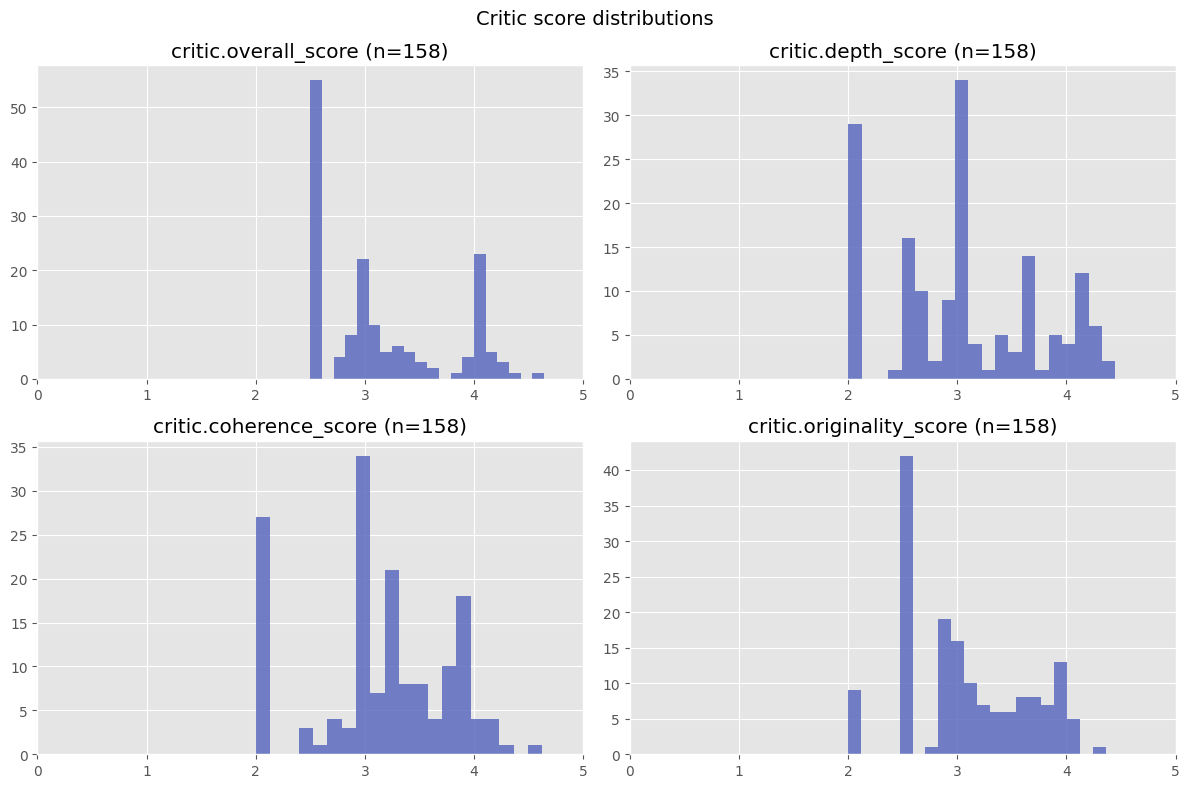

In [6]:
if not scored_flat.empty:
    fields = ['critic.overall_score', 'critic.depth_score', 'critic.coherence_score', 'critic.originality_score']
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for ax, field in zip(axes.flat, fields):
        if field not in scored_flat:
            ax.set_visible(False)
            continue
        data = scored_flat[field].dropna()
        ax.hist(data, bins=20, color='#5c6bc0', alpha=0.85)
        ax.set_title(f'{field} (n={len(data)})')
        ax.set_xlim(0, 5)
    fig.suptitle('Critic score distributions', fontsize=14)
    plt.tight_layout()


In [7]:
if not scored_flat.empty:
    seed_summary = (
        scored_flat.groupby('seed')
        .agg(
            count=('verse_id', 'count'),
            avg_overall=('critic.overall_score', 'mean'),
            avg_depth=('critic.depth_score', 'mean'),
            avg_verse_score=('verse_score', 'mean'),
            accept_rate=('accepted', 'mean'),
        )
        .sort_values('avg_overall', ascending=False)
    )
    display(seed_summary.head(10))
    display(seed_summary.tail(10))


,count,avg_overall,avg_depth,avg_verse_score,accept_rate
seed,,,,,
villain with the vacuum helmet floats past saturn,9,3.641038,3.471638,0.265363,0.000000
mask on steady while the pot slow simmers,14,3.549667,3.273217,0.375169,0.428571
microfilm vault keeps the villain manifestos safe,14,3.471028,3.326879,0.557871,0.714286
metal face alchemist mixing rhymes in the lab,19,3.418947,3.405851,0.488991,0.684211
krylon fumes and comic books on the table,14,3.389110,3.221985,0.526256,0.714286
late night deli counter trading mask-inside jokes,10,3.357863,3.426151,0.367356,0.300000
operation doomsday broadcast from the shadows,25,3.143397,2.970512,0.360004,0.280000
villain with the mask plotting on the next move,9,3.031734,2.686922,0.647180,1.000000
smoldering punchlines cooling on alloy workbenches,2,2.750000,3.500000,0.247546,0.000000


,count,avg_overall,avg_depth,avg_verse_score,accept_rate
seed,,,,,
oscillators trembling as the villain adjusts the gauge,1,2.5,2.000000,0.313484,0.000000
quantum loops folding rhyme clusters into patterns,1,2.5,2.000000,0.273119,0.000000
shadow engineer welding stanzas into steel plates,1,2.5,3.000000,0.366029,1.000000
rusted synth wires tangled in a notebook of ciphers,3,2.5,2.666667,0.387439,0.666667
subterranean echoes bouncing off reinforced conduits,1,2.5,3.000000,0.507893,1.000000
ultrasonic murmurs guiding the villain’s next scheme,2,2.5,2.000000,0.554469,1.000000
villain with the mask drafting countermeasures in code,1,2.5,2.000000,0.278909,0.000000
vectors of rhyme spiraling from a dented steel mask,2,2.5,2.000000,0.518011,1.000000
villain’s ledger coated in graphite and burnt ozone,3,2.5,3.000000,0.449209,1.000000


/tmp/ipykernel_521654/3090318955.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample('1H')


,critic.overall_score,samples,verse_score
timestamp,,,
2025-12-10 21:00:00+00:00,NaN,0,NaN
2025-12-10 22:00:00+00:00,2.666667,3,0.465855
2025-12-10 23:00:00+00:00,NaN,0,NaN
2025-12-11 00:00:00+00:00,3.509151,47,0.495172
2025-12-11 01:00:00+00:00,3.443126,53,0.382289


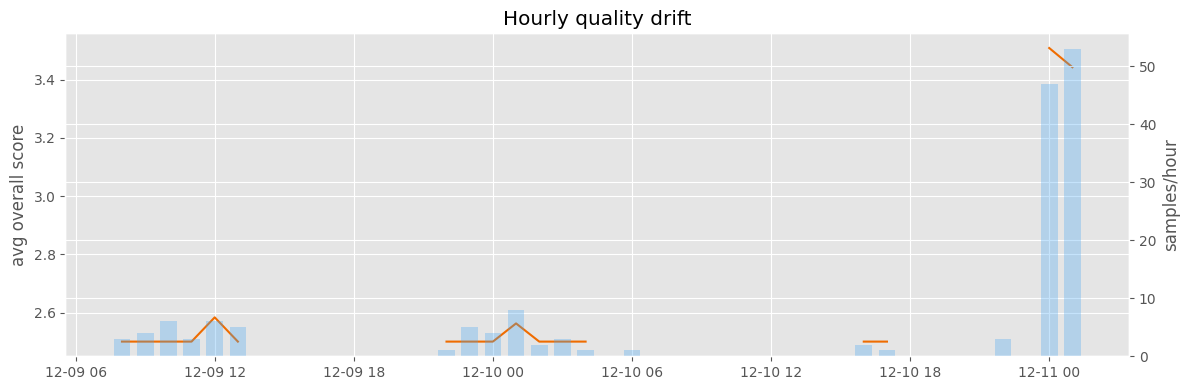

In [8]:
if 'timestamp' in scored_flat and not scored_flat['timestamp'].isna().all():
    timeline = (
        scored_flat.set_index('timestamp')
        .resample('1H')
        .agg({'critic.overall_score': 'mean', 'verse_id': 'count', 'verse_score': 'mean'})
        .rename(columns={'verse_id': 'samples'})
    )
    display(timeline.tail())
    fig, ax1 = plt.subplots(figsize=(12, 4))
    ax1.plot(timeline.index, timeline['critic.overall_score'], label='overall', color='#ef6c00')
    ax1.set_ylabel('avg overall score')
    ax2 = ax1.twinx()
    ax2.bar(timeline.index, timeline['samples'], alpha=0.3, width=0.03, label='samples/hour', color='#42a5f5')
    ax2.set_ylabel('samples/hour')
    plt.title('Hourly quality drift')
    plt.tight_layout()


In [9]:
def explode_bar_metrics(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    if df.empty or 'bar_metrics' not in df:
        return pd.DataFrame()
    for _, row in df.iterrows():
        metrics = row.get('bar_metrics') or []
        for metric in metrics:
            metric = metric or {}
            metric['verse_id'] = row['verse_id']
            metric['letter'] = metric.get('letter')
            rows.append(metric)
    return pd.DataFrame(rows)

bar_df = explode_bar_metrics(scored_flat)
if not bar_df.empty:
    stats = bar_df[['final_score', 'meter_score', 'struct_score', 'length']].describe()
    display(stats)


,final_score,meter_score,struct_score,length
count,2504.000000,2.504000e+03,2504.000000,2504.000000
mean,-1.535384,4.090232e-01,2.482923,14.582268
std,2.769218,3.930059e-01,2.154707,7.432828
min,-7.965411,7.550359e-133,-1.296027,4.000000
25%,-3.957683,1.522998e-08,0.000000,10.000000
50%,-1.696059,3.246525e-01,2.785545,11.000000
75%,0.692805,8.569969e-01,4.217756,17.000000
max,9.278568,1.000000e+00,9.479343,36.000000


### Notes
- The `seed_summary` table surfaces which prompts lead to the best critic scores.
- The timeline plot helps spot degradation when running overnight tmux jobs.
- Re-run this notebook after `score_with_openai.py`, `consolidate_stage3.py`, and `train_local_critic.py` to confirm the data feeding LoRA fine-tunes looks healthy.
